In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [7]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2   # ← carve out 20% of train as validation
)
val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

In [8]:
train_data = train_gen.flow_from_directory(
    'intel/seg_train',
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training'          # ← add this
)

val_data = train_gen.flow_from_directory(
    'intel/seg_train',
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'        # ← val comes from train folder
)

test_data = test_gen.flow_from_directory(
    'intel/seg_test',
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical'
)

Found 11228 images belonging to 1 classes.
Found 2806 images belonging to 1 classes.
Found 3000 images belonging to 1 classes.


In [9]:
model = models.Sequential()

# Conv Layer 1
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(layers.MaxPooling2D(2,2))

# Conv Layer 2
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

# Conv Layer 3
model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

# Conv Layer 4
model.add(layers.Conv2D(256, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

# Flatten
model.add(layers.Flatten())

# Dense Layer
model.add(layers.Dense(256, activation='relu'))

# Output Layer
model.add(layers.Dense(train_data.num_classes, activation='softmax'))

/Users/dnyaneshwari/Desktop/LABS/SEM_VI/DLML/py39_env/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [12]:
history = model.fit(train_data,epochs=15,validation_data=val_data)

Epoch 1/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 78s 222ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 70s 200ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 73s 208ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 72s 205ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 74s 210ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 82s 233ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 84s 239ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/15
351/351 ━━━━━━━━

In [15]:
loss, accuracy = model.evaluate(test_data)
print("Test Accuracy:", accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 12s 122ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Test Accuracy: 1.0


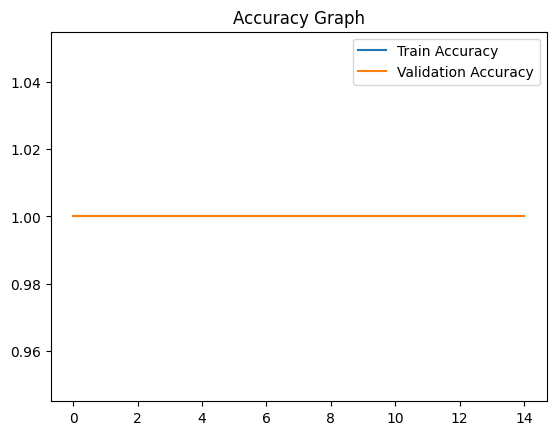

In [17]:
#acc visualization
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

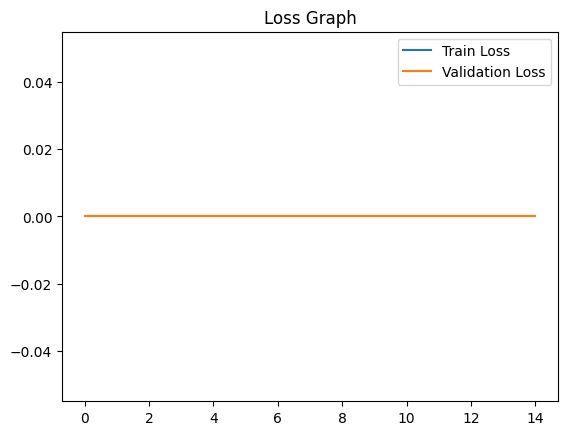

In [18]:
#loss visualization
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Graph")
plt.show()